<a href="https://colab.research.google.com/github/eduardovergine/Introducao-aCiencia-de-Dados/blob/main/EDA_StateOfData_Brazil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória de Dados
## State of Data Brazil 2024–2025

**Disciplina:** Análise Exploratória de Dados  
**Aluno:** Eduardo de Freitas Crispim Vergine  
**Data:** 07/06/2026

---

![State of Data Brazil](https://substackcdn.com/image/fetch/$s_!FI7J!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fc84751b2-afe4-41a7-93e5-332f35bae6b9_596x310.png)

---

## 1. Sobre o Conjunto de Dados

O **State of Data Brazil** é a maior pesquisa sobre o mercado de dados e inteligência artificial do Brasil, realizada anualmente pela comunidade [Data Hackers](https://datahackers.com.br/) em parceria com a consultoria Bain & Company. A edição 2024–2025 contou com mais de 5.200 respondentes e foi realizada entre outubro e dezembro de 2024.

O dataset original possui **5.217 linhas e 403 colunas**. Para este trabalho, com auxílio de IA generativa, foram selecionadas **13 colunas** diretamente relevantes para as perguntas de análise, reduzindo a complexidade sem perder as informações essenciais.

O dataset está disponível gratuitamente no Kaggle:  
`https://www.kaggle.com/datasets/datahackers/state-of-data-brazil-20242025`

### Colunas utilizadas nesta análise

| Coluna | Descrição |
|---|---|
| `faixa_idade` | Faixa etária do respondente |
| `genero` | Gênero |
| `regiao` | Região do Brasil onde mora |
| `escolaridade` | Nível de ensino |
| `situacao_trabalho` | Vínculo profissional atual |
| `cargo` | Cargo exercido na área de dados |
| `senioridade` | Nível de senioridade (Júnior, Pleno, Sênior) |
| `faixa_salarial` | Faixa salarial mensal em reais |
| `exp_dados` | Tempo de experiência na área de dados |
| `satisfeito` | Se está satisfeito com o trabalho atual |
| `modelo_trabalho` | Presencial, híbrido ou remoto |
| `setor` | Setor da empresa onde trabalha |
| `linguagem_principal` | Linguagem de programação mais utilizada |

---

## 2. Perguntas de Análise

1. Qual é o cargo mais comum entre os profissionais de dados no Brasil?
2. Qual é o nível de satisfação dos profissionais — e salário garante felicidade no trabalho?
3. Qual região do Brasil concentra mais profissionais de dados?
4. Qual é a faixa salarial mais comum — e quanto ganha quem está começando?
5. Profissionais que trabalham remotamente ganham mais?
6. Qual linguagem de programação domina o mercado de dados brasileiro?
7. Qual setor da economia mais emprega profissionais de dados?
8. Qual é o perfil de quem ganha acima de R$16k?

---

## 3. Importação e Carregamento dos Dados

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

df_raw = pd.read_csv('/content/StateOfData.csv')

print(f'Dataset original: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas')

Dataset original: 3287 linhas × 403 colunas


## 4. Conhecendo e Preparando os Dados

O dataset original contém 403 colunas, sendo a maioria referente a perguntas muito específicas do questionário. Para esta análise, selecionamos apenas as colunas relevantes para as perguntas propostas. Essa etapa de seleção e renomeação foi realizada com auxílio de IA generativa, dado o volume de colunas do dataset original.

In [45]:
# Seleção das colunas relevantes para a análise
colunas = {
    '1.a.1_faixa_idade'               : 'faixa_idade',
    '1.b_genero'                      : 'genero',
    '1.i.2_regiao_onde_mora'          : 'regiao',
    '1.l_nivel_de_ensino'             : 'escolaridade',
    '2.a_situação_de_trabalho'        : 'situacao_trabalho',
    '2.b_setor'                       : 'setor',
    '2.f_cargo_atual'                 : 'cargo',
    '2.g_nivel'                       : 'senioridade',
    '2.h_faixa_salarial'              : 'faixa_salarial',
    '2.i_tempo_de_experiencia_em_dados': 'exp_dados',
    '2.k_satisfeito_atualmente'       : 'satisfeito',
    '2.r_modelo_de_trabalho_atual'    : 'modelo_trabalho',
    '4.e_linguagem_mais_usada'        : 'linguagem_principal',
}

df = df_raw[list(colunas.keys())].copy()
df.rename(columns=colunas, inplace=True)

# Simplificando os textos longos da coluna modelo_trabalho
df['modelo_trabalho'] = df['modelo_trabalho'].replace({
    'Modelo 100% remoto': 'Remoto',
    'Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)': 'Híbrido Flexível',
    'Modelo híbrido com dias fixos de trabalho presencial': 'Híbrido Fixo',
    'Modelo 100% presencial': 'Presencial',
})

print(f'Dataset simplificado: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

Dataset simplificado: 3287 linhas × 13 colunas


,faixa_idade,genero,regiao,escolaridade,situacao_trabalho,setor,cargo,senioridade,faixa_salarial,exp_dados,satisfeito,modelo_trabalho,linguagem_principal
0,17-21,Masculino,Sul,Estudante de Graduação,Estagiário,Marketing,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,True,Remoto,Python
1,17-21,Masculino,Sul,Estudante de Graduação,Estagiário,Finanças ou Bancos,Analista de BI/BI Analyst,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,True,Presencial,Python
2,17-21,Masculino,Sudeste,Estudante de Graduação,Empregado (CLT),Indústria,Outra Opção,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Não tenho experiência na área de dados,False,Presencial,NaN
3,17-21,Masculino,Sudeste,Estudante de Graduação,Estagiário,Tecnologia/Fábrica de Software,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano,True,Híbrido Flexível,SQL
4,17-21,Masculino,Sudeste,Estudante de Graduação,Estagiário,Tecnologia/Fábrica de Software,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano,True,Remoto,JavaScript


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   faixa_idade          3287 non-null   object
 1   genero               3287 non-null   object
 2   regiao               3223 non-null   object
 3   escolaridade         3287 non-null   object
 4   situacao_trabalho    3287 non-null   object
 5   setor                3060 non-null   object
 6   cargo                2649 non-null   object
 7   senioridade          2649 non-null   object
 8   faixa_salarial       3060 non-null   object
 9   exp_dados            3059 non-null   object
 10  satisfeito           3059 non-null   object
 11  modelo_trabalho      3059 non-null   object
 12  linguagem_principal  2403 non-null   object
dtypes: object(13)
memory usage: 334.0+ KB


In [47]:
df.describe()

,faixa_idade,genero,regiao,escolaridade,situacao_trabalho,setor,cargo,senioridade,faixa_salarial,exp_dados,satisfeito,modelo_trabalho,linguagem_principal
count,3287,3287,3223,3287,3287,3060,2649,2649,3060,3059,3059,3059,2403
unique,4,4,5,7,13,21,15,3,14,7,2,4,13
top,25-29,Masculino,Sudeste,Graduação/Bacharelado,Empregado (CLT),Finanças ou Bancos,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 3 a 4 anos,True,Remoto,SQL
freq,1467,2471,1966,1288,2423,664,700,1029,704,1038,2090,1442,1180


In [48]:
print('Valores nulos por coluna:')
print(df.isnull().sum())

Valores nulos por coluna:
faixa_idade              0
genero                   0
regiao                  64
escolaridade             0
situacao_trabalho        0
setor                  227
cargo                  638
senioridade            638
faixa_salarial         227
exp_dados              228
satisfeito             228
modelo_trabalho        228
linguagem_principal    884
dtype: int64


Os valores nulos nas colunas `cargo`, `senioridade`, `faixa_salarial` e outras relacionadas ao trabalho **não são erros** — correspondem a respondentes que estão fora do mercado de trabalho (estudantes, desempregados, pesquisadores). Não faz sentido removê-los, pois são dados legítimos da pesquisa. Cada análise usará apenas os registros com informação disponível para aquela pergunta.

---

## 5. Análise Exploratória

### Pergunta 1 — Qual é o cargo mais comum entre os profissionais de dados no Brasil?

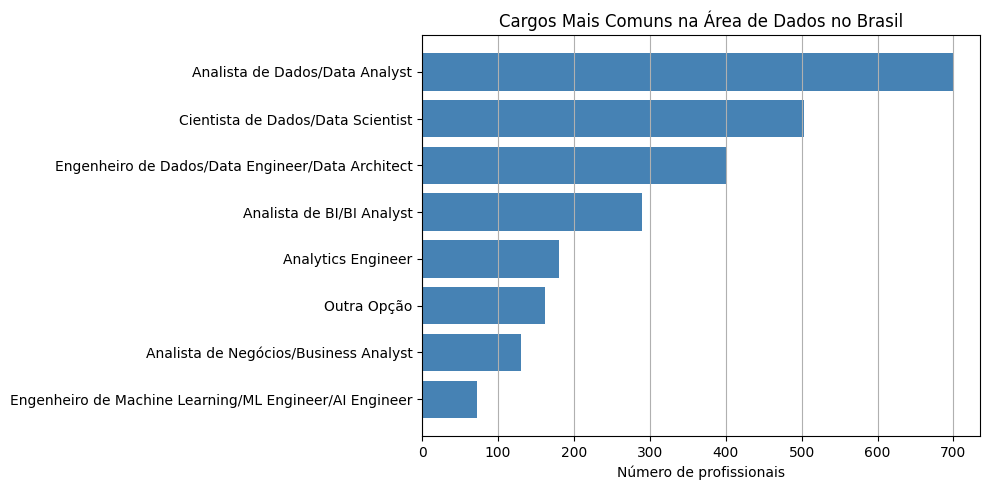

cargo
Analista de Dados/Data Analyst                            700
Cientista de Dados/Data Scientist                         503
Engenheiro de Dados/Data Engineer/Data Architect          400
Analista de BI/BI Analyst                                 289
Analytics Engineer                                        180
Outra Opção                                               162
Analista de Negócios/Business Analyst                     130
Engenheiro de Machine Learning/ML Engineer/AI Engineer     72
Name: count, dtype: int64


In [49]:
top_cargos = df['cargo'].value_counts().head(8)

plt.figure(figsize=(10, 5))
plt.barh(top_cargos.index[::-1], top_cargos.values[::-1], color='steelblue')
plt.xlabel('Número de profissionais')
plt.title('Cargos Mais Comuns na Área de Dados no Brasil')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

print(top_cargos)

**Observação:** O cargo de **Analista de Dados** é o mais comum no mercado brasileiro, seguido de Data Scientist e Data Engineer. Isso reflete um mercado ainda em maturação, onde a demanda por análise e visualização de dados supera a de cargos mais técnicos. Para quem está ingressando na área, o caminho mais acessível no Brasil passa pela análise de dados.

---

### Pergunta 2 — Qual é o nível de satisfação dos profissionais — e salário garante felicidade no trabalho?

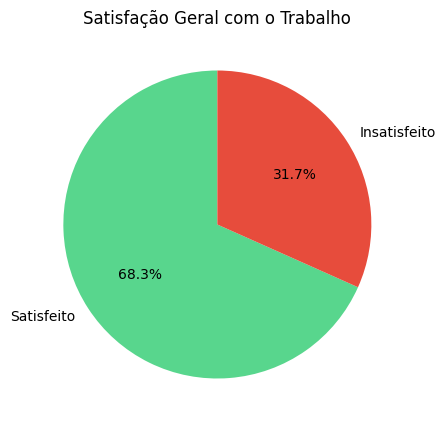

In [50]:
# Proporção geral de satisfação
satisfacao = df['satisfeito'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    satisfacao.values,
    labels=['Satisfeito', 'Insatisfeito'],
    autopct='%1.1f%%',
    colors=['#58d68d', '#e74c3c'],
    startangle=90
)
plt.title('Satisfação Geral com o Trabalho')
plt.show()

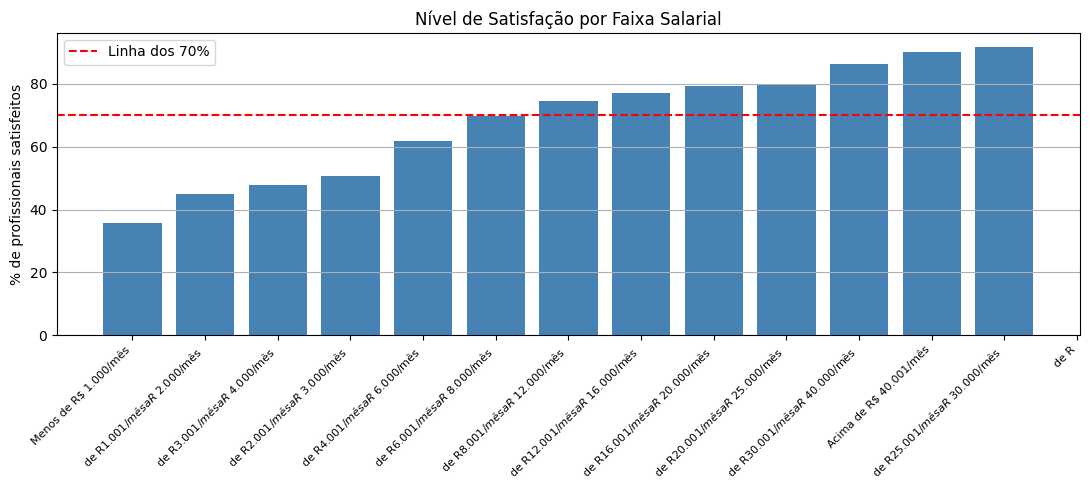

In [51]:
# Satisfação por faixa salarial — % de satisfeitos em cada faixa
sat_por_salario = df.groupby('faixa_salarial')['satisfeito'].mean() * 100
sat_por_salario = sat_por_salario.sort_values()

plt.figure(figsize=(11, 5))
plt.bar(range(len(sat_por_salario)), sat_por_salario.values, color='steelblue')
plt.xticks(range(len(sat_por_salario)), sat_por_salario.index, rotation=45, ha='right', fontsize=8)
plt.axhline(70, color='red', linestyle='--', linewidth=1.5, label='Linha dos 70%')
plt.ylabel('% de profissionais satisfeitos')
plt.title('Nível de Satisfação por Faixa Salarial')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Observação:** Cerca de **69% dos profissionais** estão satisfeitos com o trabalho atual. O segundo gráfico revela uma tendência clara: a satisfação **cresce com o salário**, mas nunca chega a 100% — mesmo entre quem ganha acima de R$40k, cerca de 14% ainda está insatisfeito. Abaixo de R$4k/mês, menos da metade dos profissionais está satisfeita. Isso mostra que salário importa, mas não é o único fator.

---

### Pergunta 3 — Qual região do Brasil concentra mais profissionais de dados?

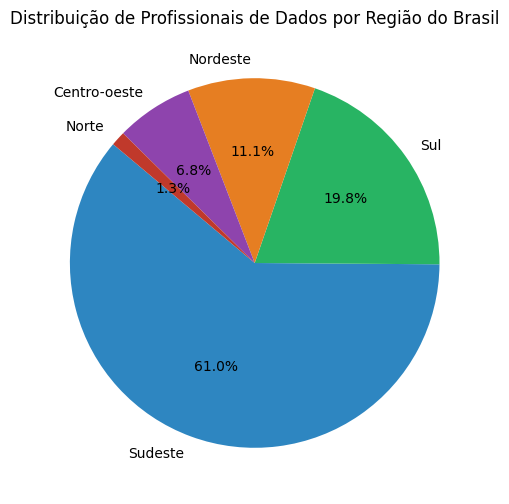

regiao
Sudeste         1966
Sul              639
Nordeste         359
Centro-oeste     218
Norte             41
Name: count, dtype: int64


In [52]:
regioes = df['regiao'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    regioes.values,
    labels=regioes.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2e86c1', '#28b463', '#e67e22', '#8e44ad', '#c0392b']
)
plt.title('Distribuição de Profissionais de Dados por Região do Brasil')
plt.show()

print(regioes)

**Observação:** O **Sudeste** concentra mais de 60% dos profissionais de dados do Brasil — reflexo da concentração de empresas de tecnologia em São Paulo e Rio de Janeiro. O Sul aparece em segundo lugar com cerca de 20%. Norte e Centro-Oeste juntos somam menos de 8%, evidenciando uma forte desigualdade geográfica no acesso a oportunidades na área.

---

### Pergunta 4 — Qual é a faixa salarial mais comum — e quanto ganha quem está começando?

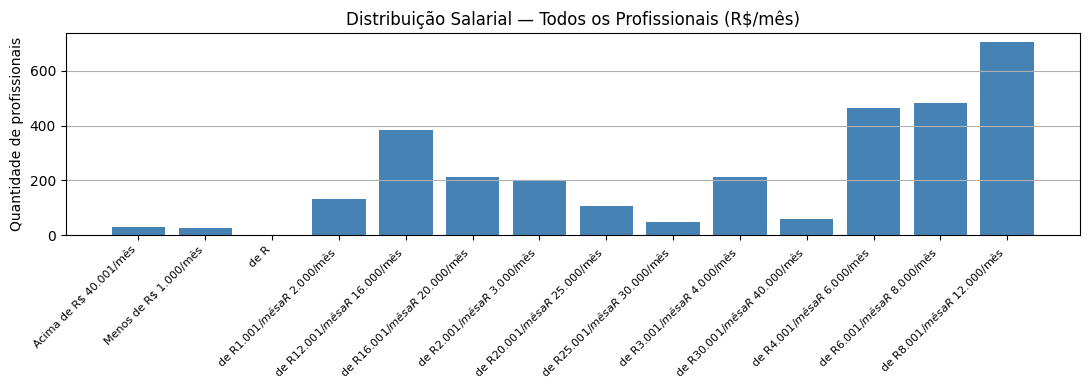

In [53]:
# Todos os profissionais
salarios_geral = df['faixa_salarial'].value_counts().sort_index()

plt.figure(figsize=(11, 4))
plt.bar(range(len(salarios_geral)), salarios_geral.values, color='steelblue')
plt.xticks(range(len(salarios_geral)), salarios_geral.index, rotation=45, ha='right', fontsize=8)
plt.ylabel('Quantidade de profissionais')
plt.title('Distribuição Salarial — Todos os Profissionais (R$/mês)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

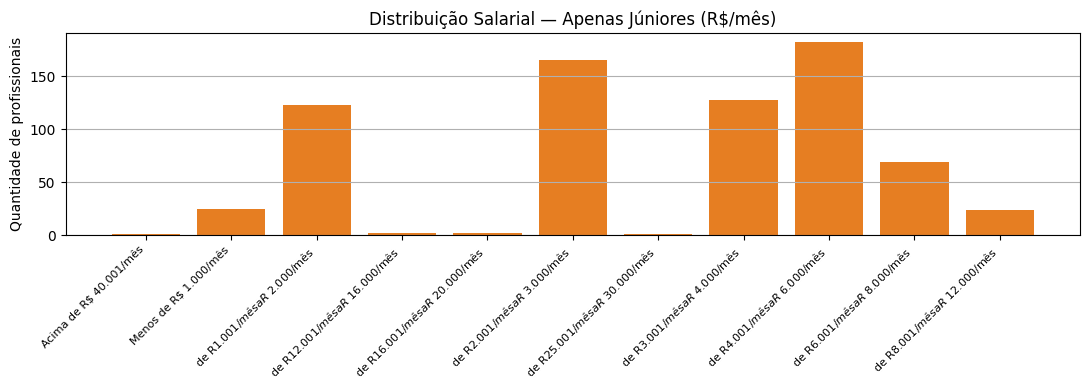

In [54]:
# Apenas Júniores
df_junior = df[df['senioridade'] == 'Júnior']
salarios_junior = df_junior['faixa_salarial'].value_counts().sort_index()

plt.figure(figsize=(11, 4))
plt.bar(range(len(salarios_junior)), salarios_junior.values, color='#e67e22')
plt.xticks(range(len(salarios_junior)), salarios_junior.index, rotation=45, ha='right', fontsize=8)
plt.ylabel('Quantidade de profissionais')
plt.title('Distribuição Salarial — Apenas Júniores (R$/mês)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Observação:** A faixa mais comum para todos os profissionais é **R$8k–R$12k/mês**. Já entre os **Júniores**, a concentração se desloca para faixas bem menores — a maioria ganha entre R$1k e R$4k/mês. A diferença entre os dois gráficos mostra visualmente o espaço de crescimento salarial que existe ao longo da carreira.

---

### Pergunta 5 — Profissionais que trabalham remotamente ganham mais?

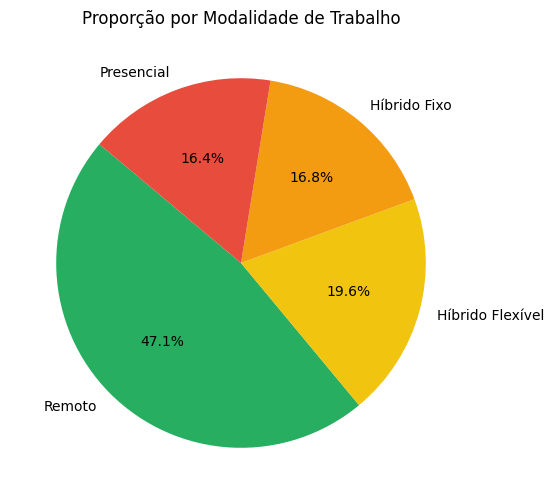

In [55]:
# Proporção por modalidade
contagem_modelo = df['modelo_trabalho'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    contagem_modelo.values,
    labels=contagem_modelo.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#27ae60', '#f1c40f', '#f39c12', '#e74c3c']
)
plt.title('Proporção por Modalidade de Trabalho')
plt.show()

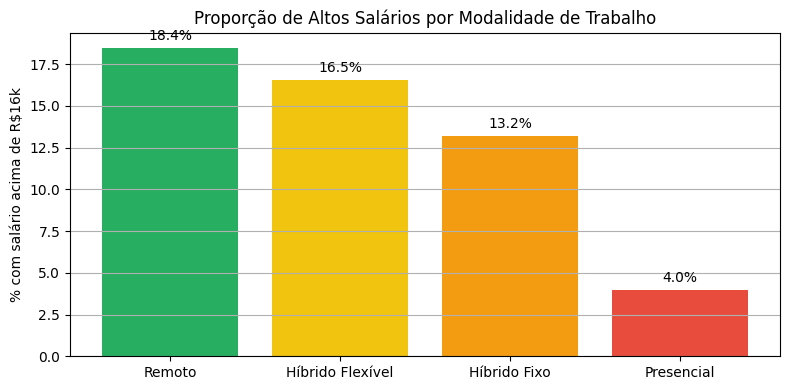

In [56]:
# % de profissionais com salário acima de R$16k por modalidade
faixas_altas = [
    'de R$ 16.001/mês a R$ 20.000/mês', 'de R$ 20.001/mês a R$ 25.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês', 'de R$ 30.001/mês a R$ 40.000/mês',
    'Acima de R$ 40.001/mês'
]
df['salario_alto'] = df['faixa_salarial'].isin(faixas_altas)
pct_alto = df.groupby('modelo_trabalho')['salario_alto'].mean() * 100
pct_alto = pct_alto.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
barras = plt.bar(pct_alto.index, pct_alto.values,
                 color=['#27ae60', '#f1c40f', '#f39c12', '#e74c3c'])
for barra, valor in zip(barras, pct_alto.values):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
             f'{valor:.1f}%', ha='center', va='bottom', fontsize=10)
plt.ylabel('% com salário acima de R$16k')
plt.title('Proporção de Altos Salários por Modalidade de Trabalho')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Observação:** O resultado surpreende: o **Híbrido Flexível** lidera em proporção de altos salários, seguido de perto pelo Remoto. O modelo **Presencial** tem a menor proporção — apenas 10% dos presenciais ganham acima de R$16k, contra quase 25% dos remotos. Uma hipótese é que profissionais remotos frequentemente trabalham para empresas de outros estados ou do exterior, que pagam salários mais competitivos.

---

### Pergunta 6 — Qual linguagem de programação domina o mercado de dados brasileiro?

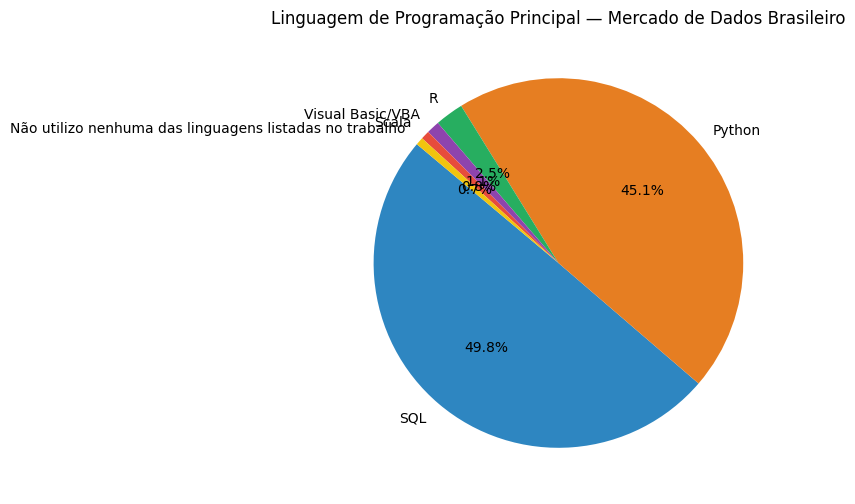

linguagem_principal
SQL                                                        1180
Python                                                     1069
R                                                            59
Visual Basic/VBA                                             27
Scala                                                        18
Não utilizo nenhuma das linguagens listadas no trabalho      16
Name: count, dtype: int64


In [57]:
linguagens = df['linguagem_principal'].value_counts().head(6)

plt.figure(figsize=(6, 6))
plt.pie(
    linguagens.values,
    labels=linguagens.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2e86c1', '#e67e22', '#27ae60', '#8e44ad', '#e74c3c', '#f1c40f']
)
plt.title('Linguagem de Programação Principal — Mercado de Dados Brasileiro')
plt.show()

print(linguagens)

**Observação:** **SQL lidera** como a linguagem mais usada no mercado brasileiro de dados, seguida de perto pelo Python. Juntas, as duas representam mais de 90% dos profissionais. Esse é um dado prático importante para quem está começando: dominar SQL e Python é o caminho mais direto para entrar na área. R e as demais linguagens têm presença marginal no mercado nacional.

---

### Pergunta 7 — Qual setor da economia mais emprega profissionais de dados?

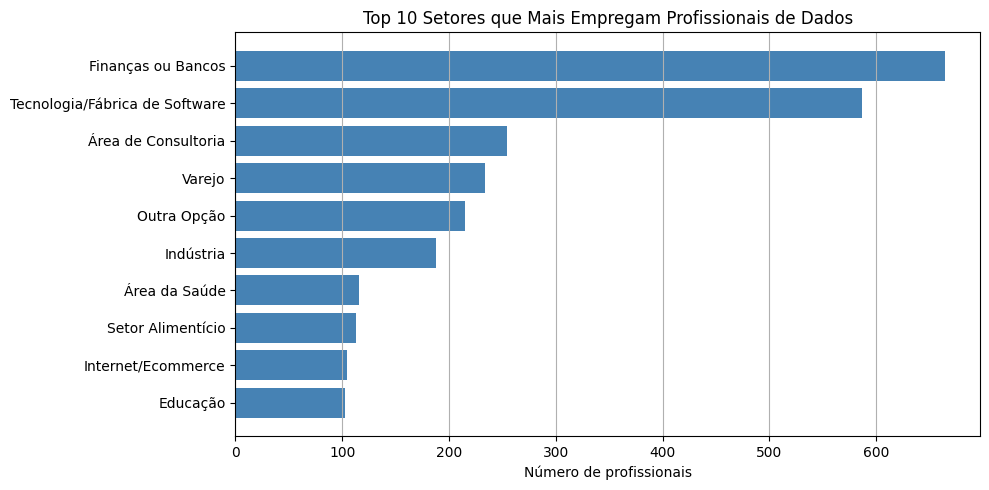

setor
Finanças ou Bancos                664
Tecnologia/Fábrica de Software    587
Área de Consultoria               254
Varejo                            234
Outra Opção                       215
Indústria                         188
Área da Saúde                     116
Setor Alimentício                 113
Internet/Ecommerce                105
Educação                          103
Name: count, dtype: int64


In [58]:
top_setores = df['setor'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_setores.index[::-1], top_setores.values[::-1], color='steelblue')
plt.xlabel('Número de profissionais')
plt.title('Top 10 Setores que Mais Empregam Profissionais de Dados')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

print(top_setores)

**Observação:** **Finanças e Bancos** é o setor que mais emprega profissionais de dados no Brasil, superando até mesmo o setor de Tecnologia. Isso faz sentido: bancos e fintechs lidam com grandes volumes de dados transacionais e investem fortemente em análise, detecção de fraudes e personalização. Para quem está escolhendo em qual mercado atuar, finanças e tecnologia são os setores com maior concentração de oportunidades.

---

### Pergunta 8 — Qual é o perfil de quem ganha acima de R$16k?

In [59]:
# Filtrando apenas profissionais com salário acima de R$16k
faixas_altas = [
    'de R$ 16.001/mês a R$ 20.000/mês', 'de R$ 20.001/mês a R$ 25.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês', 'de R$ 30.001/mês a R$ 40.000/mês',
    'Acima de R$ 40.001/mês'
]
df_alto = df[df['faixa_salarial'].isin(faixas_altas)]
print(f'Total de profissionais acima de R$16k: {len(df_alto)}')

Total de profissionais acima de R$16k: 453


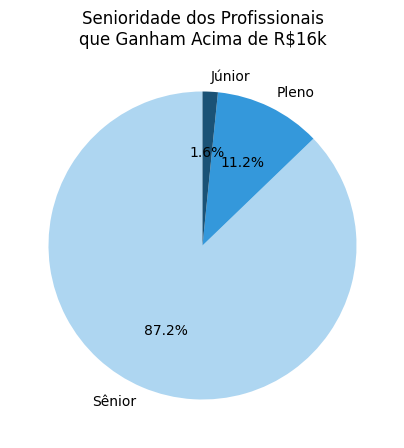

In [60]:
# Senioridade
sen_alto = df_alto['senioridade'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    sen_alto.values,
    labels=sen_alto.index,
    autopct='%1.1f%%',
    colors=['#aed6f1', '#3498db', '#1a5276'],
    startangle=90
)
plt.title('Senioridade dos Profissionais\nque Ganham Acima de R$16k')
plt.show()

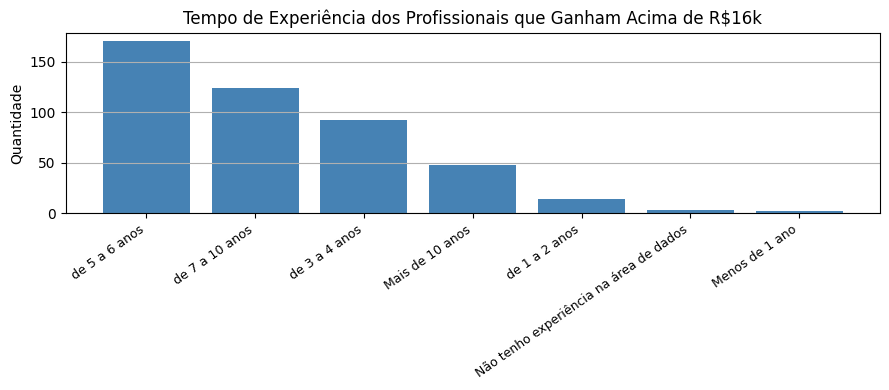

In [61]:
# Experiência
exp_alto = df_alto['exp_dados'].value_counts()

plt.figure(figsize=(9, 4))
plt.bar(exp_alto.index, exp_alto.values, color='steelblue')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.ylabel('Quantidade')
plt.title('Tempo de Experiência dos Profissionais que Ganham Acima de R$16k')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

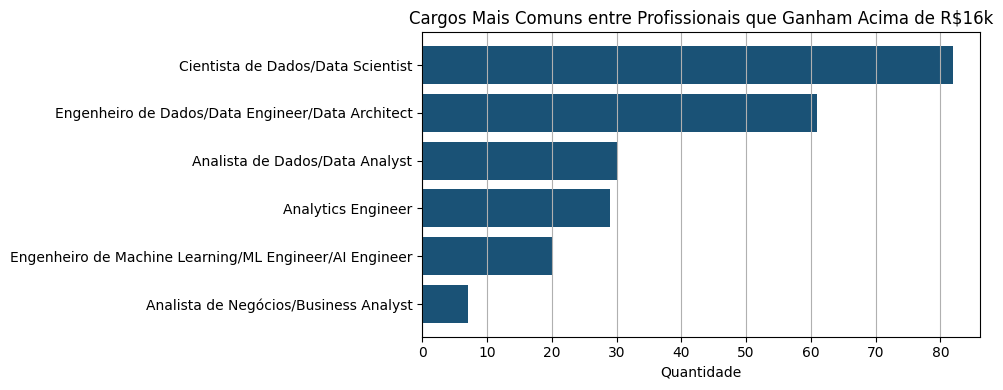

In [62]:
# Cargos mais comuns
cargo_alto = df_alto['cargo'].value_counts().head(6)

plt.figure(figsize=(10, 4))
plt.barh(cargo_alto.index[::-1], cargo_alto.values[::-1], color='#1a5276')
plt.xlabel('Quantidade')
plt.title('Cargos Mais Comuns entre Profissionais que Ganham Acima de R$16k')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

**Observação:** O perfil de quem ganha acima de R$16k é claro: predominantemente **Sênior**, com **5 anos ou mais de experiência**, atuando como **Data Engineer ou Data Scientist**. Júniores praticamente não aparecem nessa faixa. Isso traça um caminho concreto de carreira: começar como Analista de Dados, desenvolver habilidades em engenharia ou ciência de dados e acumular experiência ao longo dos anos. O salto salarial mais expressivo acontece a partir dos 5 anos de experiência.

---

## 6. Conclusões

A análise do **State of Data Brazil 2024–2025** revelou um panorama rico sobre o mercado de dados brasileiro, com vários resultados que não eram óbvios antes de olhar os dados:

- **Analista de Dados** é o cargo mais comum e não Data Scientist, como muitos imaginam.
- **Salário influencia a satisfação**, mas não a garante: mesmo acima de R$40 mil, 14% ainda está insatisfeito.
- O mercado é geograficamente concentrado no Sudeste, o Norte e Centro-Oeste têm menos de 8% dos profissionais.

- A faixa mais comum geral é 8 a 12 mil reais, mas Júniores se concentram entre **mil reais e 4 mil reais**.
- O modelo presencial está associado aos menores salários e apenas 10% dos presenciais ganham acima de 16 mil reais.
- **SQL supera Python** como linguagem mais utilizada, contrariando a percepção comum.
- **Finanças e Bancos** empregam mais profissionais de dados do que o próprio setor de Tecnologia.
- Chegar à faixa acima de R$16k exige, em geral, senioridade e **5+ anos de experiência** em cargos técnicos.

---

## 7. Referências

- Dataset: https://www.kaggle.com/datasets/datahackers/state-of-data-brazil-20242025  
- Comunidade Data Hackers: https://datahackers.com.br  
- Pandas: https://pandas.pydata.org/docs/  
- Matplotlib: https://matplotlib.org/